<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/PyTorch/Classifica%C3%A7%C3%A3o%20Binaria/base%20breast%20cancer%20%231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 1: Classificação binária brest cancer

## Etapa 1: Importação das bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
import torch
torch.__version__

'2.9.0+cu126'

In [3]:
import torch.nn as nn

## Etapa 2: Base de dados

In [4]:
np.random.seed(123)
torch.manual_seed(123)

In [5]:
previsores = pd.read_csv("/content/entradas_breast.csv")
classe = pd.read_csv("/content/saidas_breast.csv")

In [6]:
previsores.shape

(569, 30)

In [7]:
previsores.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,186.0000,275.0000,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,243.0000,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,173.00000
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,198.0000,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,205.0000,0.4000,0.1625,0.2364,0.07678


In [8]:
classe.head()

,0
0,0
1,0
2,0
3,0
4,0


In [9]:
np.unique(classe)

array([0, 1])

In [10]:
previsores_train, previsores_test, classe_train, classe_test = train_test_split(previsores, classe, test_size=0.25)

In [11]:
previsores_train.shape, classe_train.shape

((426, 30), (426, 1))

In [12]:
previsores_test.shape, classe_test.shape

((143, 30), (143, 1))

## Etapa 3: Transformação dos dados para tensores

In [13]:
type(np.array(previsores_train))

numpy.ndarray

In [14]:
previsores_train = torch.tensor(np.array(previsores_train), dtype = torch.float)
classe_train = torch.tensor(np.array(classe_train), dtype = torch.float)

In [15]:
type(previsores_train), type(classe_train)

(torch.Tensor, torch.Tensor)

In [16]:
dataset = torch.utils.data.TensorDataset(previsores_train, classe_train)

In [ ]:
type(dataset)

In [18]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size = 10, shuffle = True)

## Etapa 4: Construção do modelo

In [19]:
classificador = nn.Sequential(
    nn.Linear(in_features = 30, out_features = 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

In [21]:
criterion = nn.BCELoss()

In [22]:
optimizer = torch.optim.Adam(classificador.parameters(), lr = 0.001, weight_decay = 0.0001)

## Etapa 5: Treinamento do modelo

In [26]:
for epoch in range(100):
  running_loss = 0.

  for data in train_loader:
    inputs, labels = data
    optimizer.zero_grad()

    outputs = classificador(inputs)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print("Época %3d: perda %.5f" % (epoch + 1, running_loss/len(train_loader)))

Época   1: perda 11.10946
Época   2: perda 4.08730
Época   3: perda 1.90475
Época   4: perda 1.95414
Época   5: perda 1.76957
Época   6: perda 1.77365
Época   7: perda 1.88323
Época   8: perda 1.70686
Época   9: perda 1.72150
Época  10: perda 0.84713
Época  11: perda 0.54142
Época  12: perda 0.52198
Época  13: perda 0.51371
Época  14: perda 0.50899
Época  15: perda 0.49569
Época  16: perda 0.52447
Época  17: perda 0.46219
Época  18: perda 0.62102
Época  19: perda 0.45634
Época  20: perda 0.44834
Época  21: perda 0.46188
Época  22: perda 0.46587
Época  23: perda 0.47803
Época  24: perda 0.45657
Época  25: perda 0.44594
Época  26: perda 0.44074
Época  27: perda 0.43953
Época  28: perda 0.45139
Época  29: perda 0.58718
Época  30: perda 0.42904
Época  31: perda 0.41208
Época  32: perda 0.43129
Época  33: perda 0.43132
Época  34: perda 0.42088
Época  35: perda 0.40070
Época  36: perda 0.41282
Época  37: perda 0.41801
Época  38: perda 0.42897
Época  39: perda 0.41950
Época  40: perda 0.19697

## Etapa 6: Visualização dos pesos

In [27]:
params = list(classificador.parameters())

In [30]:
pesos0 = params[0]
pesos0.shape

torch.Size([16, 30])

## Etapa 7: Avaliação do modelo

In [31]:
classificador.eval()

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

In [ ]:
type(previsores_test)

In [40]:
previsores_teste = torch.tensor(np.array(previsores_test), dtype = torch.float)

In [41]:
type(previsores_teste)

torch.Tensor

In [42]:
previsoes = classificador.forward(previsores_teste)

In [46]:
previsoes = np.array(previsoes > 0.5)

In [47]:
taxa_acerto = accuracy_score(classe_test, previsoes)

In [48]:
taxa_acerto

0.9020979020979021

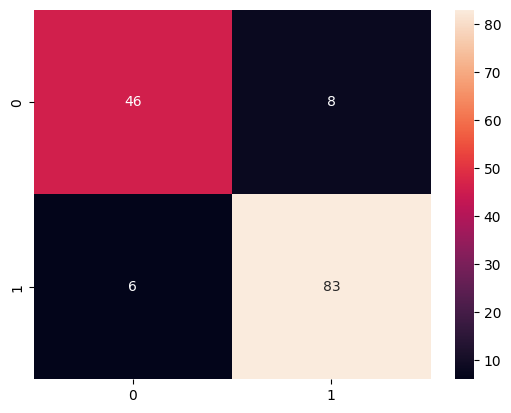

In [51]:
cm = confusion_matrix(classe_test, previsoes)
sns.heatmap(cm, annot = True);